In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

FEATURE_DATASET_PATH = r"C:\Users\Enjoy\OneDrive\Desktop\STData\final_features.csv"
MODELS_DIR = r"C:\Users\Enjoy\OneDrive\Desktop\STData\models"

os.makedirs(MODELS_DIR, exist_ok=True)
sns.set_style("whitegrid")

print("Configuration complete.")

Configuration complete.


In [2]:
print("--- Loading the feature dataset ---")
try:
    df = pd.read_csv(FEATURE_DATASET_PATH)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print(f"Error: Dataset not found at '{FEATURE_DATASET_PATH}'. Please check the path.")

--- Loading the feature dataset ---
Dataset loaded successfully.


In [3]:
print("--- 1. First 5 Rows of the Dataset ---")
display(df.head())



--- 1. First 5 Rows of the Dataset ---


,trial_id,response_time,eeg_delta_mean,eeg_delta_std,eeg_delta_var,eeg_delta_min,eeg_delta_max,eeg_delta_spectral_entropy,eeg_theta_mean,eeg_theta_std,...,eye_pupil_mean,eye_pupil_std,eye_pupil_var,eye_pupil_min,eye_pupil_max,eye_gaze_variability,eye_avg_fixation_duration,eye_fixation_count,eye_avg_saccade_amplitude,eye_blink_count
0,student_1_trial_0,10.369816,0.239537,0.146903,0.021580,-0.020135,0.567931,1.172398,0.176614,0.071372,...,0.190284,1.777635,3.159986,-1.0,3.382889,439.711293,1358.819046,1097,7.773025,882
1,student_1_trial_10,9.659429,0.878957,0.181840,0.033066,0.104589,1.174160,0.309628,0.717378,0.205096,...,0.112260,1.705860,2.909959,-1.0,3.629654,498.161723,345.905025,980,7.329646,847
2,student_1_trial_11,21.042414,0.931256,0.184803,0.034152,0.577722,1.333250,0.255953,0.616433,0.178468,...,0.108177,1.715587,2.943238,-1.0,3.520447,543.885934,322.570735,2005,8.103427,1803
3,student_1_trial_12,6.252160,0.350807,0.096269,0.009268,0.164777,0.475770,0.385995,0.130774,0.068989,...,0.036304,1.640583,2.691511,-1.0,3.485512,537.724470,253.741274,590,6.617334,558
4,student_1_trial_13,7.533956,0.856298,0.199314,0.039726,0.452667,1.067846,0.319499,0.405921,0.243591,...,0.204319,1.807572,3.267316,-1.0,3.480156,549.312576,260.036277,722,7.980705,648


In [4]:
print("\n--- 2. Dataset Structure and Data Types ---")
df.info()




--- 2. Dataset Structure and Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trial_id                    235 non-null    object 
 1   response_time               235 non-null    float64
 2   eeg_delta_mean              235 non-null    float64
 3   eeg_delta_std               235 non-null    float64
 4   eeg_delta_var               235 non-null    float64
 5   eeg_delta_min               235 non-null    float64
 6   eeg_delta_max               235 non-null    float64
 7   eeg_delta_spectral_entropy  235 non-null    float64
 8   eeg_theta_mean              235 non-null    float64
 9   eeg_theta_std               235 non-null    float64
 10  eeg_theta_var               235 non-null    float64
 11  eeg_theta_min               235 non-null    float64
 12  eeg_theta_max               235 non-null    flo


--- 3. Descriptive Statistics ---


,response_time,eeg_delta_mean,eeg_delta_std,eeg_delta_var,eeg_delta_min,eeg_delta_max,eeg_delta_spectral_entropy,eeg_theta_mean,eeg_theta_std,eeg_theta_var,...,eye_pupil_mean,eye_pupil_std,eye_pupil_var,eye_pupil_min,eye_pupil_max,eye_gaze_variability,eye_avg_fixation_duration,eye_fixation_count,eye_avg_saccade_amplitude,eye_blink_count
count,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,...,235.000000,235.000000,235.000000,235.0,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000
mean,8.321712,0.712549,0.164242,0.033085,0.385700,0.987979,0.493815,0.416952,0.136818,0.023029,...,0.311615,1.964177,4.030226,-1.0,3.859934,522.814064,277.947564,615.765957,5.937798,754.897872
std,7.549507,0.387558,0.078328,0.032471,0.454088,0.370592,0.552620,0.328500,0.065789,0.022092,...,0.349105,0.415898,1.471008,0.0,0.545555,81.359621,177.497165,488.197952,2.012760,801.584690
min,0.435931,-0.088127,0.012754,0.000163,-0.586531,0.079289,0.001409,-0.252681,0.015773,0.000249,...,-0.976040,0.227540,0.051774,-1.0,1.288429,242.264417,89.279007,21.000000,0.486007,35.000000
25%,4.095509,0.509534,0.101407,0.010283,0.116221,0.801306,0.132387,0.246228,0.089199,0.007957,...,0.199573,1.798585,3.234912,-1.0,3.475605,482.629510,200.255189,290.000000,4.612713,335.000000
50%,6.372439,0.679468,0.147875,0.021867,0.345682,0.942444,0.293154,0.373632,0.127563,0.016272,...,0.368005,2.027079,4.109049,-1.0,3.889114,522.788502,245.802179,461.000000,6.305017,558.000000
75%,9.997472,0.862326,0.210488,0.044305,0.576885,1.152852,0.663756,0.547738,0.179574,0.032247,...,0.547686,2.229838,4.972180,-1.0,4.124161,561.890259,315.794896,783.500000,7.432981,875.000000
max,62.452913,2.891129,0.461308,0.212805,2.664165,3.078947,3.341607,2.264293,0.365904,0.133886,...,0.869955,2.657734,7.063552,-1.0,5.180901,776.010629,2370.859575,3396.000000,10.543612,6829.000000



--- 4. Distribution of the Target Variable (response_time) ---


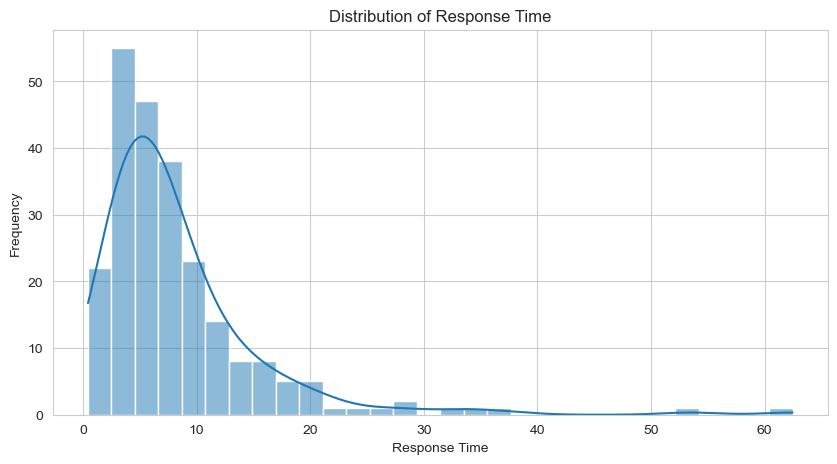

In [5]:
print("\n--- 3. Descriptive Statistics ---")
display(df.describe())

print("\n--- 4. Distribution of the Target Variable (response_time) ---")
plt.figure(figsize=(10, 5))
sns.histplot(df['response_time'], kde=True, bins=30)
plt.title('Distribution of Response Time')
plt.xlabel('Response Time')
plt.ylabel('Frequency')
plt.show()

In [6]:
print("--- Fixing Data Leakage by Creating Rate-Based Features ---")

if 'eye_blink_count' in df.columns and 'response_time' in df.columns:
    epsilon = 1e-9 # Prevents division by zero
    df['blink_rate'] = df['eye_blink_count'] / (df['response_time'] + epsilon)
    df['fixation_rate'] = df['eye_fixation_count'] / (df['response_time'] + epsilon)
    df.drop(columns=['eye_blink_count', 'eye_fixation_count'], inplace=True)
    print("  -> New rate-based features created and leaky features dropped.\n")
else:
    print("  -> Rate-based features already exist or required columns are missing. Skipping step.\n")

--- Fixing Data Leakage by Creating Rate-Based Features ---
  -> New rate-based features created and leaky features dropped.



In [7]:
print("--- Separating features (X) and target (y) ---")
X = df.drop(columns=['trial_id', 'response_time'])
y = df['response_time']
print(f"Features matrix X created with shape: {X.shape}")

--- Separating features (X) and target (y) ---
Features matrix X created with shape: (235, 41)


In [8]:
print("--- Splitting data into training (80%) and testing (20%) sets ---")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}, Testing set shape: {X_test.shape}")

--- Splitting data into training (80%) and testing (20%) sets ---
Training set shape: (188, 41), Testing set shape: (47, 41)


In [9]:
print("--- Engineering Polynomial and Interaction Features ---")
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
print(f"  -> Number of features expanded to {X_train_poly.shape[1]}.\n")

--- Engineering Polynomial and Interaction Features ---
  -> Number of features expanded to 902.



In [10]:
print("--- Scaling Features using RobustScaler ---")
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)
print("  -> All features scaled successfully.\n")

--- Scaling Features using RobustScaler ---
  -> All features scaled successfully.



In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(random_state=42, eval_metric='rmse') # Corrected metric
}
param_grid = {
    'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1], 'subsample': [0.8, 1.0]
}
xgb_grid_search = GridSearchCV(estimator=models["XGBoost"], param_grid=param_grid, cv=5, n_jobs=-1, scoring='r2', verbose=1)
results = {}
best_model_object = None
best_r2 = -float('inf')

print("--- Starting Model Training and Evaluation ---\n")
for name in ["Linear Regression", "Random Forest"]:
    model = models[name]
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"R2 Score": r2}
    print(f"--- Trained {name} with R2 Score: {r2:.4f} ---")
    if r2 > best_r2: best_model_object = model

print("\n--- Training and Tuning XGBoost (this may take a moment) ---")
xgb_grid_search.fit(X_train_scaled, y_train)
best_xgb = xgb_grid_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_scaled)
r2_xgb = r2_score(y_test, y_pred_xgb)
results["XGBoost (Tuned)"] = {"R2 Score": r2_xgb}
if r2_xgb > best_r2: best_model_object = best_xgb

print("\nModel training complete.")

--- Starting Model Training and Evaluation ---

--- Trained Linear Regression with R2 Score: -1.9586 ---
--- Trained Random Forest with R2 Score: 0.2908 ---

--- Training and Tuning XGBoost (this may take a moment) ---
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Model training complete.


In [12]:
print("\n--- Best Parameters Found for XGBoost ---")
print(xgb_grid_search.best_params_)
print(f"\n-> Tuned XGBoost R2 Score: {r2_xgb:.4f}\n")

results_df = pd.DataFrame(results).T.sort_values(by="R2 Score", ascending=False)
print("--- Final Model Comparison ---")
display(results_df)


--- Best Parameters Found for XGBoost ---
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

-> Tuned XGBoost R2 Score: 0.3913

--- Final Model Comparison ---


,R2 Score
XGBoost (Tuned),0.391279
Random Forest,0.290755
Linear Regression,-1.958577


In [13]:
joblib.dump(best_model_object, os.path.join(MODELS_DIR, "best_model.pkl"))
joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler.pkl"))
joblib.dump(poly, os.path.join(MODELS_DIR, "poly_features.pkl"))

print(f" Best model ({best_model_object.__class__.__name__}) and associated processors have been saved.")

 Best model (XGBRegressor) and associated processors have been saved.


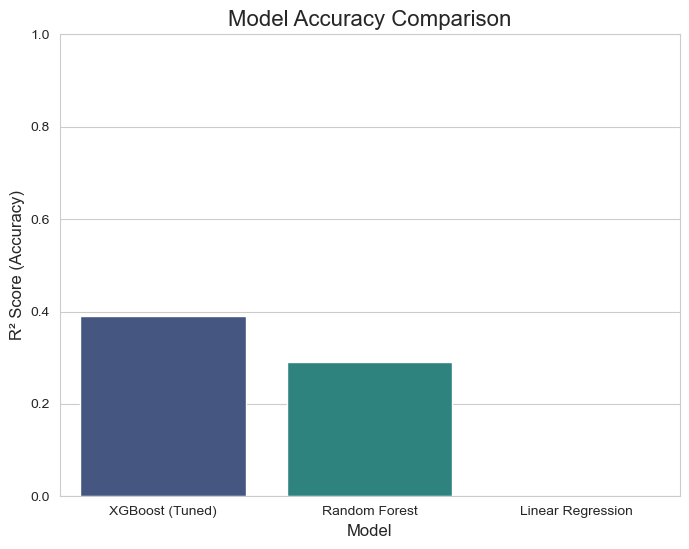

In [14]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=results_df.index, 
    y=results_df['R2 Score'], 
    palette='viridis'  
)

plt.title('Model Accuracy Comparison', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('R² Score (Accuracy)', fontsize=12)

plt.ylim(0, 1)

plt.show()